# Task 3 — Fine-Grained 7-Class Classification of OT-VA Site of Origin (OPTIONAL, +0.5p)

Classify the origin into 7 anatomical sublocations from Yamada (2016):


- LCC --> Left Coronary Cusp --> LVOT
- RCC --> Right Coronary Cusp --> LVOT
- COMMISSURE --> LCC-RCC inter-sinus --> LVOT
- LVOT Subvalvular --> Subvalvular LVOT --> LVOT
- LVOT Summit --> LV Summit --> LVOT
- RVOT Septum --> RVOT septal wall --> RVOT
- RFW --> RVOT Free Wall --> RVOT

### Limitations of this task

The 7-class problem inherits all the limitations of Task 2 and makes them worse:
- Some classes have **only 5-10 training patients** in Teknon (LCC, RCC, COMMISSURE, LVOT Subvalvular).
- The 26-patient test set will have classes with **1-2 patients** — single-sample F1 swings.
- The **literature** explicitly identifies this as the bottleneck (Doste et al. 2022, Frontiers Physiol) --> "Machine learning algorithms can automatize the process and improve generalization, but their performance is hampered by the lack of large enough OTVA databases."


### The three strategies compared
1. **Multimodal ResNet ensemble** (ECG branch + clinical branch + MixUp + Focal Loss + 5-fold ensemble) --> Deep learning --> He et al. 2016 *(CVPR)* — ResNet; Lin et al. 2017 *(ICCV)* — Focal Loss; Zhang et al. 2018 *(ICLR)* — MixUp; Lakshminarayanan et al. 2017 *(NeurIPS)* — deep ensembles
2. **Linear SVM + SelectKBest** on flattened ECG + clinical --> Classical ML (HDLSS) --> Cortes & Vapnik 1995 *(Mach Learn)* — SVM; Hall 1999 — SelectKBest; Bühlmann & van de Geer 2011 — HDLSS theory
3. **Late-fusion ensemble** (50/50 average of ResNet + SVM probabilities) --> Multi-model fusion --> Polikar 2006 *(IEEE Circuits Syst Mag)* — ensemble surveys; Kuncheva 2014 *(Wiley)* — combining classifiers


## 1. Setup & Imports

In [1]:
# We load all the necessary libraries
import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from scipy.signal import resample
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Some checks
print(f"PyTorch Version: {torch.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # checks if GPU is available and uses if it is. If not, uses the CPU.
print(f"Using Device: {DEVICE}")

# Paths to the three data files
TEKNON_PATH     = r"./data/full_data_corrected_2024.pkl"
SAMPLE_SIZE = 128
FS_TEKNON = 1000
ECG_LEADS_TEKNON = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]

PyTorch Version: 2.12.0
Using Device: cpu


---
## 2. Data Loading & 7-Class Mapping

In [2]:
with open(TEKNON_PATH, "rb") as f:
    teknon = pickle.load(f)

clinical_df = pd.DataFrame({k: v for k, v in teknon.items() if k not in ECG_LEADS_TEKNON})

SOO_MAPPING = {
    "LCC": "LCC", "Left coronary cusp": "LCC", "Cúspide izquierda": "LCC",
    "Seno de Valsalva izdo.": "LCC", "LVOT Seno de Valsalva izdo.": "LCC",
    "LVOT Seno de Valsava izdo.": "LCC",
    "RCC": "RCC", "Seno de Valsalva dcho.": "RCC",
    "Intersenos dcho.-izdo.": "COMMISSURE", "LVOT intersenos dcho.-izdo.": "COMMISSURE",
    "Intersenos": "COMMISSURE", "Intersenos (LV)": "COMMISSURE", "Intersinus": "COMMISSURE",
    "Unión mitroaórtica": "LVOT Subvalvular", "Septo basal subaótico": "LVOT Subvalvular",
    "Postero Septal Subvalvular": "LVOT Subvalvular",
    "Septo posterior, immediatamente subvalvular": "LVOT Subvalvular",
    "LVOT anterolateral": "LVOT Subvalvular",
    "Summit": "LVOT Summit", "LV summit": "LVOT Summit",
    "LV summit EPI (SC)": "LVOT Summit", "CS distal (summit)": "LVOT Summit",
    "subvalvular aortico (summit)": "LVOT Summit",
    "RVOT septal": "RVOT Septum", "RVOT medioseptal": "RVOT Septum",
    "RVOT anteroseptal": "RVOT Septum", "RVOT posteroseptal": "RVOT Septum",
    "rvot postero septal": "RVOT Septum", "rvot septo posterior": "RVOT Septum",
    "rvot sèeto posterior": "RVOT Septum", "rvot septal anterior": "RVOT Septum",
    "RVOT septal subvalvular": "RVOT Septum", "RVOT subvalvular septal": "RVOT Septum",
    "RVOT anteroseptal subvalvular": "RVOT Septum",
    "RVOT posterior": "RVOT Septum", "RVOT anterior": "RVOT Septum",
    "Septo anterior": "RVOT Septum", "septo": "RVOT Septum",
    "RVOT": "RVOT Septum", "Infundíbulo": "RVOT Septum",
    "Infudibulo": "RVOT Septum", "Infundibulo": "RVOT Septum",
    "Pared libre anterior": "RFW", "pared libre anterior": "RFW",
    "RVOT anterolateral": "RFW", "RVOT posterolateral": "RFW",
    "rvot pared libre": "RFW", "rvot - pared libre": "RFW",
    "Pared libre anterolateral": "RFW", "RVOT lateral": "RFW",
    "RVOT lateral + septal": "RFW",
}

CLASS_TO_INT = {"LCC":0, "RCC":1, "COMMISSURE":2, "LVOT Subvalvular":3,
                "LVOT Summit":4, "RVOT Septum":5, "RFW":6}
target_names_7 = [k for k, v in sorted(CLASS_TO_INT.items(), key=lambda item: item[1])]

def map_soo(raw):
    if isinstance(raw, float) and np.isnan(raw): return "UNCERTAIN"
    return SOO_MAPPING.get(raw, "EXCLUDE")

clinical_df["SOO_std"] = clinical_df["SOO"].apply(map_soo)
clinical_df["is_OT"] = clinical_df["SOO_std"].isin(CLASS_TO_INT.keys())
clinical_df_OT = clinical_df[clinical_df["is_OT"]].reset_index().rename(
    columns={"index": "__orig_idx__"})

# Same 80/20 split as Tasks 1 and 2
n_train_pool = int(0.8 * len(clinical_df_OT))
teknon_train = clinical_df_OT.iloc[:n_train_pool].reset_index(drop=True)
teknon_test  = clinical_df_OT.iloc[n_train_pool:].reset_index(drop=True)

y_train_7 = np.array([CLASS_TO_INT[v] for v in teknon_train["SOO_std"]])
y_test_7  = np.array([CLASS_TO_INT[v] for v in teknon_test["SOO_std"]])

print(f"Train: {len(y_train_7)}  |  Test: {len(y_test_7)}")
print("\n── 7-class balance (train) ──")
for c, name in enumerate(target_names_7):
    print(f"  {c}: {name:20s} train={ (y_train_7==c).sum() }  test={ (y_test_7==c).sum() }")

print("\nSome classes have only 1-5 patients in test → their F1 will be very noisy.")


Train: 102  |  Test: 26

── 7-class balance (train) ──
  0: LCC                  train=5  test=5
  1: RCC                  train=6  test=2
  2: COMMISSURE           train=10  test=3
  3: LVOT Subvalvular     train=11  test=1
  4: LVOT Summit          train=12  test=4
  5: RVOT Septum          train=40  test=5
  6: RFW                  train=18  test=6

Some classes have only 1-5 patients in test → their F1 will be very noisy.


---
## 3. Feature Extraction (used by all three models)


In [3]:
def extract_and_reshape_ecg(df, win_size=SAMPLE_SIZE, n_leads=12):
    """RMS-based QRS extraction. More robust than lead-II-only max."""
    orig_idx = df["__orig_idx__"].values
    X_3d = np.zeros((len(orig_idx), n_leads, win_size), dtype=np.float32)
    for i, idx in enumerate(orig_idx):
        sigs = np.stack([np.asarray(teknon[lead][idx]).squeeze()
                        for lead in ECG_LEADS_TEKNON], axis=-1)
        last_sec = sigs[-FS_TEKNON:, :] if sigs.shape[0] >= FS_TEKNON else sigs

        # RMS across leads: more robust for low-amplitude PVCs
        rms = np.sqrt(np.mean(last_sec**2, axis=1))
        r_peak_local = np.argmax(rms)
        r_peak_global = sigs.shape[0] - last_sec.shape[0] + r_peak_local

        lo = max(0, r_peak_global - win_size * 4)
        hi = min(sigs.shape[0], r_peak_global + win_size * 8)
        qrs_segment = sigs[lo:hi, :]
        if qrs_segment.shape[0] != win_size:
            qrs_segment = resample(qrs_segment, win_size, axis=0)
        for j in range(n_leads):
            X_3d[i, j, :] = normalize(qrs_segment[:, j].reshape(1, -1), norm="l1")
    return X_3d

X_ecg_train = extract_and_reshape_ecg(teknon_train)
X_ecg_test  = extract_and_reshape_ecg(teknon_test)

# Z-normalize ECG per lead (using TRAIN stats only)
lead_mean = X_ecg_train.mean(axis=(0, 2), keepdims=True)
lead_std  = X_ecg_train.std(axis=(0, 2), keepdims=True) + 1e-6
X_ecg_train = (X_ecg_train - lead_mean) / lead_std
X_ecg_test  = (X_ecg_test  - lead_mean) / lead_std

# Clinical features
def build_clinical_features(df):
    feats = pd.DataFrame(index=df.index)
    for c in ["Age","Height","Weight","BMI","CLINICAL_SCORE"]:
        feats[c] = pd.to_numeric(df[c], errors="coerce")
    feats["Sex_M"] = df["Sex"].map({"M":1,"F":0,"Male":1,"Female":0,1:1,0:0})
    for c in ["HTA","DM","DLP","Smoker","COPD","Sleep_apnea"]:
        feats[c] = df[c].map({"Yes":1,"No":0,1:1,0:0})
    def enc_t(v):
        if pd.isna(v): return np.nan
        try: return float(str(v).upper().replace("V","").strip())
        except: return np.nan
    feats["PVC_transition"] = df["PVC_transition"].apply(enc_t)
    return feats

imputer = SimpleImputer(strategy="median")
scaler_clin = StandardScaler()
X_clin_train = scaler_clin.fit_transform(imputer.fit_transform(
    build_clinical_features(teknon_train)))
X_clin_test  = scaler_clin.transform(imputer.transform(
    build_clinical_features(teknon_test)))
n_clin_feats = X_clin_train.shape[1]

print(f"X_ecg_train:  {X_ecg_train.shape}   (12 leads × 128 samples)")
print(f"X_clin_train: {X_clin_train.shape}  ({n_clin_feats} clinical features)")


X_ecg_train:  (102, 12, 128)   (12 leads × 128 samples)
X_clin_train: (102, 13)  (13 clinical features)


## STRATEGY 1 — Multimodal ResNet Ensemble (Deep Learning)

In [4]:
class MultimodalDataset(Dataset):
    """Two-input dataset: ECG tensor + clinical vector."""
    
    # Defines the PyTorch Dataset for multimodal data. It has two inputs instead of one (ECG and clinical). Converts NumPy arrays to PyTorch tensors.
    def __init__(self, X_ecg, X_clin, y, augment=False):
        self.X_ecg = torch.from_numpy(X_ecg).float()
        self.X_clin = torch.from_numpy(X_clin).float()
        self.y = torch.from_numpy(y).long()
        self.augment = augment
    
    def __len__(self): return len(self.y)
    # For each patient, it returns their ECG, clinical variables, and label. If augment=True, it applies the three augmentations to the ECG.
    def __getitem__(self, idx):
        x_ecg = self.X_ecg[idx].clone()
        x_clin = self.X_clin[idx].clone()
        if self.augment:
            x_ecg = x_ecg * np.random.uniform(0.85, 1.15)
            if np.random.rand() > 0.5:
                x_ecg = torch.roll(x_ecg, shifts=np.random.randint(-4, 5), dims=1)
            x_ecg = x_ecg + torch.randn_like(x_ecg) * np.random.uniform(0.01, 0.04)
        return x_ecg, x_clin, self.y[idx]


# The residual block. The heart of ResNet
class ResBlock1d(nn.Module):
    """Standard 1-D residual block (He et al. 2016)."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(channels)
    def forward(self, x):
        residual = x
        out = F.leaky_relu(self.bn1(self.conv1(x)), 0.1)
        out = self.bn2(self.conv2(out))
        return F.leaky_relu(out + residual, 0.1)


# Arquitectura del ResNet multimodal con tres partes: ECG branch, Clinical branch, Classifie
class Multimodal_ResNet(nn.Module):
    """Two-branch network: ECG ResNet + clinical MLP → fused classifier."""
    def __init__(self, n_clinical_features, n_classes=7):
        super().__init__()
        self.ecg_branch = nn.Sequential(
            nn.Conv1d(12, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.LeakyReLU(0.1),
            ResBlock1d(64), nn.MaxPool1d(2),
            ResBlock1d(64), nn.MaxPool1d(2),
            ResBlock1d(64), nn.AdaptiveAvgPool1d(1)
        )
        self.clin_branch = nn.Sequential(
            nn.Linear(n_clinical_features, 16),
            nn.BatchNorm1d(16), nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(64 + 16, 64), nn.ReLU(),
            nn.Dropout(0.2), nn.Linear(64, n_classes)
        )
    # Forward pass
    def forward(self, x_ecg, x_clin):
        e = self.ecg_branch(x_ecg).squeeze(-1)
        return self.classifier(torch.cat((e, self.clin_branch(x_clin)), dim=1))


# Focal loss implementation
class FocalLoss(nn.Module):
    """Focal Loss (Lin et al. 2017)."""
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()


# Train 5-fold ensemble
ensemble_models = []
kf = KFold(n_splits=5, shuffle=True, random_state=42) # KFold divides the 103 patients into 5 groups. shuffle=True shuffles before dividing. random_state=42 sets the seed for reproducibility.
print("Training Multimodal ResNet Ensemble (5 folds)...")

# For each fold, it creates a new model from scratch, the training dataset with augmentation and the validation dataset without augmentation
for k, (tr_idx, val_idx) in enumerate(kf.split(X_ecg_train)):
    model = Multimodal_ResNet(n_clinical_features=n_clin_feats, n_classes=7).to(DEVICE)
    train_ds = MultimodalDataset(X_ecg_train[tr_idx], X_clin_train[tr_idx],
                                  y_train_7[tr_idx], augment=True)
    val_ds   = MultimodalDataset(X_ecg_train[val_idx], X_clin_train[val_idx],
                                  y_train_7[val_idx], augment=False)

    # Balanced sampling (more aggressive than class_weight alone)
    class_counts = np.maximum(np.bincount(y_train_7[tr_idx], minlength=7), 1)
    weights = torch.from_numpy(np.array(
        [1.0 / class_counts[t] for t in y_train_7[tr_idx]])).double()
    sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=16, sampler=sampler, drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)

    # Class weights for Focal Loss
    cw = compute_class_weight("balanced", classes=np.unique(y_train_7[tr_idx]),
                               y=y_train_7[tr_idx])
    weight_tensor = torch.ones(7).to(DEVICE)
    for idx, c in enumerate(np.unique(y_train_7[tr_idx])):
        weight_tensor[c] = cw[idx]
    criterion = FocalLoss(alpha=weight_tensor, gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

    # Training loop
    best_f1, best_state, pc = 0.0, None, 0
    for epoch in range(60):
        model.train()
        for x_e, x_c, yb in train_loader:
            x_e, x_c, yb = x_e.to(DEVICE), x_c.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            # MixUp augmentation
            if np.random.rand() > 0.5:
                lam = np.random.beta(0.2, 0.2)
                index = torch.randperm(x_e.size(0)).to(DEVICE)
                mixed_x_e = lam * x_e + (1 - lam) * x_e[index, :]
                mixed_x_c = lam * x_c + (1 - lam) * x_c[index, :]
                out = model(mixed_x_e, mixed_x_c)
                loss = lam * criterion(out, yb) + (1 - lam) * criterion(out, yb[index])
            else:
                out = model(x_e, x_c)
                loss = criterion(out, yb)
            loss.backward(); optimizer.step()

        # After each epoch, evaluates in validation.
        # If the F1 improves, save the model weights (early stopping). 
        # If it does not improve for 15 consecutive epochs, stop training.
        model.eval()
        ap, at = [], []
        with torch.no_grad():
            for x_e, x_c, yb in val_loader:
                pred = model(x_e.to(DEVICE), x_c.to(DEVICE)).argmax(1).cpu().numpy()
                ap.extend(pred); at.extend(yb.numpy())
        f1 = f1_score(at, ap, average="macro")
        if f1 > best_f1:
            best_f1 = f1
            best_state = {k_: v.cpu().clone() for k_, v in model.state_dict().items()}
            pc = 0
        else:
            pc += 1
            if pc >= 15: break

    # Restores the best weights and saves the model to the ensemble list
    model.load_state_dict(best_state)
    ensemble_models.append(model)
    print(f"  Fold {k+1}/5  val F1: {best_f1:.3f}")

# Extract test probabilities (averaged over 5 models)
test_ecg_tensor = torch.from_numpy(X_ecg_test).float().to(DEVICE)
test_clin_tensor = torch.from_numpy(X_clin_test).float().to(DEVICE)
# Final ensemble prediction. Runs the 26 patients in the test through the 5 models, sums their probabilities, and divides by 5 to obtain the mean.
resnet_probs_tensor = torch.zeros((len(test_ecg_tensor), 7)).to(DEVICE)
with torch.no_grad():
    for m in ensemble_models:
        m.eval()
        resnet_probs_tensor += F.softmax(m(test_ecg_tensor, test_clin_tensor), dim=1)
resnet_probs = (resnet_probs_tensor / len(ensemble_models)).cpu().numpy()

y_pred_resnet = np.argmax(resnet_probs, axis=1)
resnet_acc = accuracy_score(y_test_7, y_pred_resnet)
resnet_f1  = f1_score(y_test_7, y_pred_resnet, average="macro")
print(f"\nStrategy 1 — Multimodal ResNet Ensemble:")
print(f"Acc: {resnet_acc:.3f}  |  Macro F1: {resnet_f1:.3f}\n")
print(classification_report(y_test_7, y_pred_resnet, target_names=target_names_7,
                            digits=3, zero_division=0))


Training Multimodal ResNet Ensemble (5 folds)...
  Fold 1/5  val F1: 0.245
  Fold 2/5  val F1: 0.233
  Fold 3/5  val F1: 0.284
  Fold 4/5  val F1: 0.287
  Fold 5/5  val F1: 0.210

Strategy 1 — Multimodal ResNet Ensemble:
Acc: 0.308  |  Macro F1: 0.231

                  precision    recall  f1-score   support

             LCC      0.000     0.000     0.000         5
             RCC      0.125     0.500     0.200         2
      COMMISSURE      0.200     0.333     0.250         3
LVOT Subvalvular      0.000     0.000     0.000         1
     LVOT Summit      0.500     0.500     0.500         4
     RVOT Septum      0.000     0.000     0.000         5
             RFW      0.667     0.667     0.667         6

        accuracy                          0.308        26
       macro avg      0.213     0.286     0.231        26
    weighted avg      0.263     0.308     0.275        26



## STRATEGY 2 — Linear SVM with Feature Selection (HDLSS approach)

In [5]:
# Flatten ECG to (N, 1536) and fuse with clinical
X_train_flat = X_ecg_train.reshape(X_ecg_train.shape[0], -1)
X_test_flat  = X_ecg_test.reshape(X_ecg_test.shape[0], -1)

X_train_fused = np.hstack((X_train_flat, X_clin_train))
X_test_fused  = np.hstack((X_test_flat, X_clin_test))

# Standardize (required for linear SVM)
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train_fused)
X_test_scaled  = scaler_svm.transform(X_test_fused)

# Univariate feature selection — top 150 by ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=150)
X_train_sel = selector.fit_transform(X_train_scaled, y_train_7)
X_test_sel  = selector.transform(X_test_scaled)

print(f"After selection: train shape = {X_train_sel.shape}, test shape = {X_test_sel.shape}")

# Linear SVM with strong regularization (small C)
lsvm = LinearSVC(C=0.01, class_weight="balanced", max_iter=5000, random_state=42)
lsvm.fit(X_train_sel, y_train_7)

# Convert decision function to probabilities (softmax with temperature)
# *: LinearSVC has no predict_proba — we softmax the decision_function to enable downstream probability fusion.
svm_logits = lsvm.decision_function(X_test_sel)
TEMPERATURE = 1.5   # softens overconfident SVM margins for fusion
exp_logits = np.exp(svm_logits / TEMPERATURE)
svm_probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

y_pred_svm = np.argmax(svm_probs, axis=1)
svm_acc = accuracy_score(y_test_7, y_pred_svm)
svm_f1  = f1_score(y_test_7, y_pred_svm, average="macro")
print(f"\nStrategy 2 — Linear SVM + SelectKBest:")
print(f"Acc: {svm_acc:.3f}  |  Macro F1: {svm_f1:.3f}\n")
print(classification_report(y_test_7, y_pred_svm, target_names=target_names_7,
                            digits=3, zero_division=0))


After selection: train shape = (102, 150), test shape = (26, 150)

Strategy 2 — Linear SVM + SelectKBest:
Acc: 0.308  |  Macro F1: 0.229

                  precision    recall  f1-score   support

             LCC      1.000     0.200     0.333         5
             RCC      0.000     0.000     0.000         2
      COMMISSURE      0.000     0.000     0.000         3
LVOT Subvalvular      0.000     0.000     0.000         1
     LVOT Summit      0.286     0.500     0.364         4
     RVOT Septum      0.375     0.600     0.462         5
             RFW      0.667     0.333     0.444         6

        accuracy                          0.308        26
       macro avg      0.332     0.233     0.229        26
    weighted avg      0.462     0.308     0.311        26



## STRATEGY 3 — Late-Fusion Ensemble (ResNet + SVM probabilities)

In [6]:
# The 50/50 average of the ResNet and SVM probabilities for each patient. 
ALPHA = 0.5

fused_probs = ALPHA * resnet_probs + (1 - ALPHA) * svm_probs
y_pred_fused = np.argmax(fused_probs, axis=1) # argmax takes the index of the class with the highest probability as the final prediction.

fused_acc = accuracy_score(y_test_7, y_pred_fused)
fused_f1  = f1_score(y_test_7, y_pred_fused, average="macro")

print(f"Strategy 3 — Late-Fusion Ensemble (ResNet + SVM):")
print(f"Acc: {fused_acc:.3f}  |  Macro F1: {fused_f1:.3f}\n")
print(classification_report(y_test_7, y_pred_fused, target_names=target_names_7,
                            digits=3, zero_division=0))


Strategy 3 — Late-Fusion Ensemble (ResNet + SVM):
Acc: 0.346  |  Macro F1: 0.249

                  precision    recall  f1-score   support

             LCC      0.000     0.000     0.000         5
             RCC      0.143     0.500     0.222         2
      COMMISSURE      0.200     0.333     0.250         3
LVOT Subvalvular      0.000     0.000     0.000         1
     LVOT Summit      0.500     0.500     0.500         4
     RVOT Septum      0.000     0.000     0.000         5
             RFW      0.714     0.833     0.769         6

        accuracy                          0.346        26
       macro avg      0.222     0.310     0.249        26
    weighted avg      0.276     0.346     0.300        26



---
## 4. Final Comparison + Per-Class Diagnostics


In [7]:
# Trivial baseline (most-frequent class)
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_sel, y_train_7)
y_pred_dummy = dummy.predict(X_test_sel)
dummy_acc = accuracy_score(y_test_7, y_pred_dummy)
dummy_f1  = f1_score(y_test_7, y_pred_dummy, average="macro")

print("TASK 3 — FINAL COMPARISON (test = last 20% Teknon, n=26):")
print(f"{'Strategy':50s} {'Acc':>10s} {'Macro F1':>10s}")
print(f"{'-'*50} {'-'*10} {'-'*10}")
print(f"{'Trivial baseline (predict majority class)':50s} {dummy_acc:>10.3f} {dummy_f1:>10.3f}")
print(f"{'1 — Multimodal ResNet Ensemble':50s} {resnet_acc:>10.3f} {resnet_f1:>10.3f}")
print(f"{'2 — Linear SVM + SelectKBest':50s} {svm_acc:>10.3f} {svm_f1:>10.3f}")
print(f"{'3 — Late-Fusion (ResNet + SVM, 50/50)':50s} {fused_acc:>10.3f} {fused_f1:>10.3f}")


TASK 3 — FINAL COMPARISON (test = last 20% Teknon, n=26):
Strategy                                                  Acc   Macro F1
-------------------------------------------------- ---------- ----------
Trivial baseline (predict majority class)               0.192      0.046
1 — Multimodal ResNet Ensemble                          0.308      0.231
2 — Linear SVM + SelectKBest                            0.308      0.229
3 — Late-Fusion (ResNet + SVM, 50/50)                   0.346      0.249


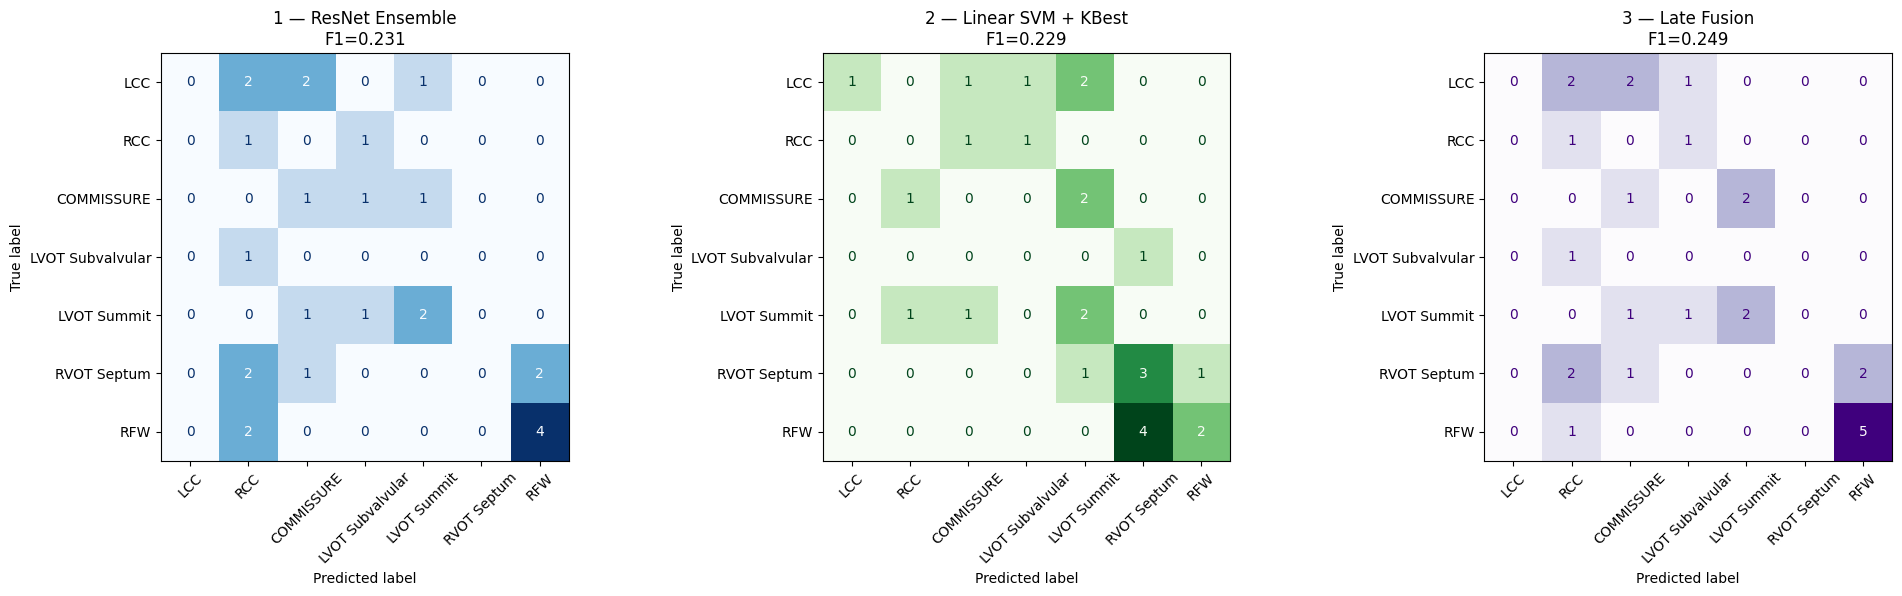

In [8]:
# Three confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ConfusionMatrixDisplay(
    confusion_matrix(y_test_7, y_pred_resnet, labels=list(range(7))),
    display_labels=target_names_7
).plot(cmap="Blues", ax=axes[0], colorbar=False, xticks_rotation=45)
axes[0].set_title(f"1 — ResNet Ensemble\nF1={resnet_f1:.3f}")

ConfusionMatrixDisplay(
    confusion_matrix(y_test_7, y_pred_svm, labels=list(range(7))),
    display_labels=target_names_7
).plot(cmap="Greens", ax=axes[1], colorbar=False, xticks_rotation=45)
axes[1].set_title(f"2 — Linear SVM + KBest\nF1={svm_f1:.3f}")

ConfusionMatrixDisplay(
    confusion_matrix(y_test_7, y_pred_fused, labels=list(range(7))),
    display_labels=target_names_7
).plot(cmap="Purples", ax=axes[2], colorbar=False, xticks_rotation=45)
axes[2].set_title(f"3 — Late Fusion\nF1={fused_f1:.3f}")

plt.tight_layout()
plt.show()


### 4.1 Per-class breakdown

In [9]:
# Per-class diagnostics
print("Class distribution in TEST set:")
for c, name in enumerate(target_names_7):
    n_test = (y_test_7 == c).sum()
    n_train = (y_train_7 == c).sum()
    mark = "X (zero in test)" if n_test == 0 else "OK"
    print(f"  {name:20s}: train={n_train:3d}, test={n_test:2d}  {mark}")

# Identify present classes
present_classes = [c for c in range(7) if (y_test_7 == c).sum() > 0]
present_names = [target_names_7[c] for c in present_classes]

print(f"\nMacro-F1 computed over {len(present_classes)}/7 classes present in test.")
print(f"Theoretical maximum macro-F1 with all classes scored = sum / 7;")
print(f"effective ceiling considering only present classes ≈ sum / {len(present_classes)} × {len(present_classes)/7:.2f}")


Class distribution in TEST set:
  LCC                 : train=  5, test= 5  OK
  RCC                 : train=  6, test= 2  OK
  COMMISSURE          : train= 10, test= 3  OK
  LVOT Subvalvular    : train= 11, test= 1  OK
  LVOT Summit         : train= 12, test= 4  OK
  RVOT Septum         : train= 40, test= 5  OK
  RFW                 : train= 18, test= 6  OK

Macro-F1 computed over 7/7 classes present in test.
Theoretical maximum macro-F1 with all classes scored = sum / 7;
effective ceiling considering only present classes ≈ sum / 7 × 1.00
